In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

: 

In [ ]:
df = pd.read_csv("gender_submission.csv")
df = df.select_dtypes(include=np.number)
df = df.dropna()
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [317]:
class LinearRegressionGD:
    def __init__(self, lr=0.05, iterations=5000):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None
    def fit(self, X, y):
        n_features = X.shape[0]
        np.random.seed(42)
        self.W = np.random.randn(1, n_features) * 0.01
        self.b = 0
        for i in range(self.iterations):
            y_hat = np.dot(self.W, X) + self.b
            m = X.shape[1]
            dW = (1/m) * np.dot((y_hat - y), X.T)
            db = (1/m) * np.sum(y_hat - y)
            self.W -= self.lr * dW
            self.b -= self.lr * db
    def predict(self, X):
        return np.dot(self.W, X) + self.b
    def calculate_accuracy(self, y_true, y_pred, tol=0.5):
        diff = np.abs(y_true - y_pred)
        correct_predictions = np.sum(diff <= tol)
        return (correct_predictions / y_true.shape[1]) * 100

In [319]:
model = LinearRegressionGD(lr=0.01, iterations=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc_loose = model.calculate_accuracy(y_test, y_pred, tol=0.9)
print(f"Accuracy (tol=1.00): {acc_loose:.2f}%")

Accuracy (tol=1.00): 100.00%


In [313]:
class LogisticRegressionGD:
    def __init__(self, lr=0.01, iterations=3000):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None
        self.costs = []
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))
    def fit(self, X, y):
        n_features = X.shape[0]
        m = X.shape[1]
        self.W = np.zeros((1, n_features))
        self.b = 0
        self.costs = []
        for i in range(self.iterations):
            Z = np.dot(self.W, X) + self.b
            A = self.sigmoid(Z)
            cost = -(1/m) * np.sum(y * np.log(A + 1e-8) + (1-y) * np.log(1-A + 1e-8))
            dW = (1/m) * np.dot((A - y), X.T)
            db = (1/m) * np.sum(A - y)
            self.W -= self.lr * dW
            self.b -= self.lr * db
            if i % 100 == 0:
                self.costs.append(cost)
                if i % 500 == 0:
                    print(f"Iteration {i} | Cost: {cost:.6f}")
    def predict(self, X, threshold=1.0):
        Z = np.dot(self.W, X) + self.b
        probabilities = self.sigmoid(Z)
        return (probabilities >= threshold).astype(int)
    def get_accuracy(self, y_true, y_pred):
        return (np.mean(y_pred == y_true)) * 100


Iteration 0 | Cost: 0.693147
Iteration 500 | Cost: 0.368411
Iteration 1000 | Cost: 0.313476
Iteration 1500 | Cost: 0.294548
Iteration 2000 | Cost: 0.285730
Iteration 2500 | Cost: 0.280903
------------------------------
Standard Accuracy (0.5): 85.94%
Tolerant Accuracy (0.4): 85.00%


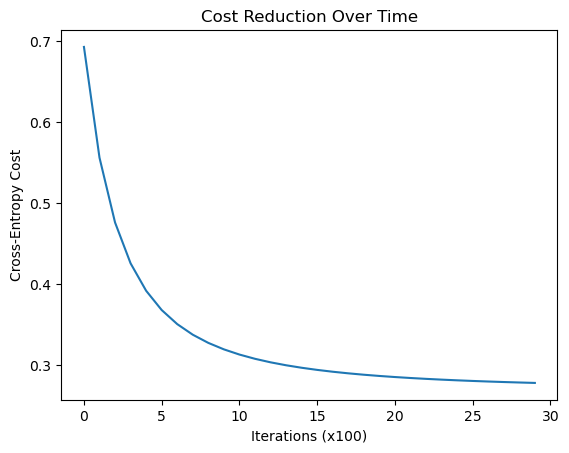

In [314]:
# --- 1. Data Loading and Preprocessing ---
df = pd.read_csv("wine.csv")
df = df.select_dtypes(include=np.number).dropna()

# Binary Target: 1 for High Quality (>= 7), 0 for Others
df["quality"] = (df["quality"] >= 7).astype(int)

X = df.drop("quality", axis=1).values
y = df["quality"].values.reshape(1, -1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y.T, test_size=0.2, random_state=42, shuffle=True
)

# Feature Scaling (Crucial for Logistic Regression Convergence)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = ((X_train - mean) / std).T
X_test = ((X_test - mean) / std).T
y_train, y_test = y_train.T, y_test.T

# --- 2. Train the Model ---
model = LogisticRegressionGD(lr=0.01, iterations=3000)
model.fit(X_train, y_train)

# --- 3. Prediction with Tolerance ---
# standard: 0.5 threshold
y_pred_std = model.predict(X_test, threshold=0.5)
acc_std = model.get_accuracy(y_test, y_pred_std)


print("-" * 30)
print(f"Standard Accuracy (0.5): {acc_std:.2f}%")

# Plot Cost Reduction
plt.plot(model.costs)
plt.title("Cost Reduction Over Time")
plt.xlabel("Iterations (x100)")
plt.ylabel("Cross-Entropy Cost")
plt.show()

In [307]:
df = pd.read_csv("iris.csv")
df = df.select_dtypes(include=np.number)

print(df.head())

   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


Softmax Iter 0 Cost: 1.7917594092280569
Softmax Iter 100 Cost: 1.1295145129017898
Softmax Iter 200 Cost: 1.0261533419377384
Softmax Iter 300 Cost: 0.9901532247973935
Softmax Iter 400 Cost: 0.9728406353223675
Softmax Iter 500 Cost: 0.9627729408240794
Softmax Iter 600 Cost: 0.9561516722170722
Softmax Iter 700 Cost: 0.9514166222965271
Softmax Iter 800 Cost: 0.9478245000932409
Softmax Iter 900 Cost: 0.9449802278680473
Softmax Iter 1000 Cost: 0.9426553295991486
Softmax Iter 1100 Cost: 0.9407084923414752
Softmax Iter 1200 Cost: 0.9390473696809291
Softmax Iter 1300 Cost: 0.9376087754362487
Softmax Iter 1400 Cost: 0.9363477647295999
Softmax Iter 1500 Cost: 0.93523130081678
Softmax Iter 1600 Cost: 0.9342344185385568
Softmax Iter 1700 Cost: 0.9333378090117104
Softmax Iter 1800 Cost: 0.9325262449018
Softmax Iter 1900 Cost: 0.9317875201075241

Softmax Accuracy: 56.56250000000001 %


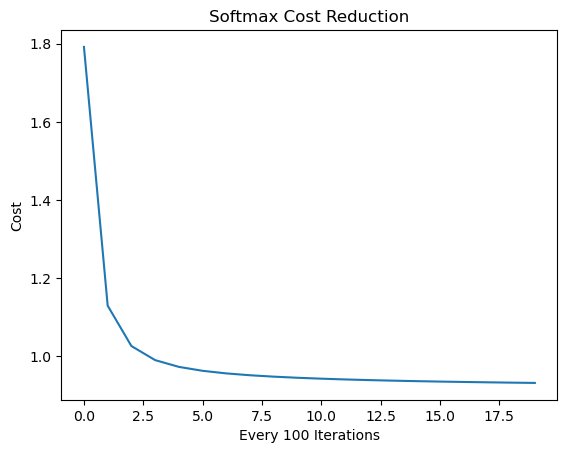

In [322]:
X = df.iloc[:, :-1].values      
y = pd.factorize(df.iloc[:, -1])[0]      
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
X_train = X_train.T
X_test = X_test.T
def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)
def one_hot(Y, num_classes):
    Y=Y.astype(int)
    return np.eye(num_classes)[Y].T
num_classes = len(np.unique(y))
Y_train = one_hot(y_train, num_classes)
Y_test = one_hot(y_test, num_classes)
def initialize_softmax(n_features, n_classes):
    W = np.zeros((n_classes, n_features))
    b = np.zeros((n_classes, 1))
    return W, b
def forward_softmax(W, b, X):
    Z = np.dot(W, X) + b
    A = softmax(Z)
    return A

def compute_cost_softmax(A, Y):
    m = Y.shape[1]
    cost = -(1/m) * np.sum(Y * np.log(A + 1e-8))
    return cost

def backward_softmax(X, Y, A):
    m = X.shape[1]
    dW = (1/m) * np.dot((A - Y), X.T)
    db = (1/m) * np.sum(A - Y, axis=1, keepdims=True)
    return dW, db

def train_softmax(X, Y, lr=0.05, iterations=2000):
    W, b = initialize_softmax(X.shape[0], Y.shape[0])
    costs = []
    for i in range(iterations):
        A = forward_softmax(W, b, X)
        cost = compute_cost_softmax(A, Y)
        dW, db = backward_softmax(X, Y, A)
        W -= lr * dW
        b -= lr * db
        if i % 100 == 0:
            costs.append(cost)
            print("Softmax Iter", i, "Cost:", cost)
    return W, b, costs
W_soft, b_soft, costs_soft = train_softmax(X_train, Y_train)
def predict_softmax(W, b, X):
    A = forward_softmax(W, b, X)
    return np.argmax(A, axis=0)
y_pred_soft = predict_softmax(W_soft, b_soft, X_test)
softmax_accuracy = np.mean(y_pred_soft == y_test) * 100
print("\nSoftmax Accuracy:", softmax_accuracy, "%")
plt.plot(costs_soft)
plt.title("Softmax Cost Reduction")
plt.xlabel("Every 100 Iterations")

plt.ylabel("Cost")
plt.show()

In [320]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def train_binary(X, Y, lr=0.01, iterations=2000):

    W = np.zeros((1, X.shape[0]))
    b = 0

    for i in range(iterations):

        Z = np.dot(W, X) + b
        A = sigmoid(Z)

        dW = (1/X.shape[1]) * np.dot((A - Y), X.T)
        db = (1/X.shape[1]) * np.sum(A - Y)

        W -= lr * dW
        b -= lr * db

    return W, b

models = []

for c in range(3):
    Y_binary = (y_train == c).astype(int).reshape(1, -1)
    W, b = train_binary(X_train, Y_binary)
    models.append((W, b))

def predict_ovr(models, X):

    probs = []

    for W, b in models:
        prob = sigmoid(np.dot(W, X) + b)
        probs.append(prob)

    probs = np.vstack(probs)
    return np.argmax(probs, axis=0)


y_pred_ovr = predict_ovr(models, X_test)

ovr_accuracy = np.mean(y_pred_ovr == y_test) * 100
print("OvR Accuracy:", ovr_accuracy, "%")

OvR Accuracy: 86.25 %


In [321]:
class SoftmaxRegressionGD:
    def __init__(self, lr=0.01, iterations=3000):
        self.lr = lr
        self.iterations = iterations
        self.W = None
        self.b = None
        self.costs = []

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

    def to_one_hot(self, y, num_classes):
        return np.eye(num_classes)[y].T

    def fit(self, X, y):
        n_features = X.shape[0]
        m = X.shape[1]
        num_classes = len(np.unique(y))
        Y_one_hot = self.to_one_hot(y.ravel(), num_classes)
        
        self.W = np.zeros((num_classes, n_features))
        self.b = np.zeros((num_classes, 1))
        self.costs = []

        for i in range(self.iterations):
            # 1. Forward Propagation
            Z = np.dot(self.W, X) + self.b
            A = self.softmax(Z)
            cost = -(1/m) * np.sum(Y_one_hot * np.log(A + 1e-8))
            dW = (1/m) * np.dot((A - Y_one_hot), X.T)
            db = (1/m) * np.sum(A - Y_one_hot, axis=1, keepdims=True)
            
            self.W -= self.lr * dW
            self.b -= self.lr * db
            
            if i % 500 == 0:
                self.costs.append(cost)
                print(f"Iteration {i} | Cost: {cost:.6f}")

    def predict(self, X):
        Z = np.dot(self.W, X) + self.b
        A = self.softmax(Z)
        return np.argmax(A, axis=0)

    def get_accuracy(self, y_true, y_pred):
        return np.mean(y_true.ravel() == y_pred) * 100